# Notebook 5: Sequential Testing

## Campaign Experimentation Framework

This notebook demonstrates **group-sequential hypothesis testing** — a principled method for monitoring experiments in real-time without inflating the false positive rate.

### The Core Problem

Campaign teams often want to stop an experiment early if results look promising. But stopping based on a single p < 0.05 observation inflates Type-I error because the experiment is tested multiple times.

### The Solution: O'Brien-Fleming Boundaries

Group-sequential methods pre-plan a fixed number of interim looks and distribute alpha across them using a **spending function**. The O'Brien-Fleming (OBF) boundary is conservative at early looks (requires very strong evidence to stop early) and converges to the nominal α at the final look.

**Key concepts:**
- **Efficacy boundary**: stop and declare winner if |z| exceeds this
- **Futility boundary**: stop to preserve resources if |z| is below this
- **Always-valid CIs**: confidence intervals that maintain coverage at any stopping time

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import warnings
warnings.filterwarnings("ignore")

from config import SIGNIFICANCE_LEVEL, POWER, VISUALS_DIR
from src.sequential_testing import SequentialTester, SequentialBoundary, SequentialDecision
from src.visualizations import ExperimentVisualizer

VISUALS_PATH = PROJECT_ROOT / VISUALS_DIR
VISUALS_PATH.mkdir(parents=True, exist_ok=True)

tester = SequentialTester(
    alpha=SIGNIFICANCE_LEVEL,
    power=POWER,
    n_looks=5,
    spending_function="obrien_fleming"
)
visualizer = ExperimentVisualizer(visuals_dir=VISUALS_PATH)

print(f"Alpha               : {tester.alpha}")
print(f"Power               : {tester.power}")
print(f"Number of looks     : {tester.n_looks}")
print(f"Spending function   : {tester.spending_function}")

Alpha               : 0.05
Power               : 0.8
Number of looks     : 5
Spending function   : obrien_fleming


## 2. The Peeking Problem

### Why naive monitoring destroys your alpha

If you run a null experiment (no true effect) but check the p-value at each of 100 daily observations, the probability of ever seeing p < 0.05 far exceeds 5%. This is the **peeking problem**.

We simulate this by running 1,000 null experiments and checking whether p < 0.05 at *any* of 10 looks.

In [2]:
from scipy import stats as sp

rng = np.random.default_rng(42)
n_simulations = 1_000
n_per_look    = 100   # observations per arm per look
n_looks_peek  = 10
alpha         = 0.05
baseline_rate = 0.20   # no true treatment effect

false_positive_naive  = 0  # peeking at each look
false_positive_final  = 0  # only at final look

for _ in range(n_simulations):
    control_obs   = []
    treatment_obs = []
    ever_significant = False

    for look in range(n_looks_peek):
        # Both groups drawn from same distribution (null = true)
        control_obs.extend(rng.binomial(1, baseline_rate, size=n_per_look).tolist())
        treatment_obs.extend(rng.binomial(1, baseline_rate, size=n_per_look).tolist())

        c_arr = np.array(control_obs)
        t_arr = np.array(treatment_obs)
        n_c, n_t = len(c_arr), len(t_arr)

        p_pool = (c_arr.sum() + t_arr.sum()) / (n_c + n_t)
        se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t)) if p_pool not in (0, 1) else 1e-9
        z = (t_arr.mean() - c_arr.mean()) / se
        p_val = 2 * (1 - sp.norm.cdf(abs(z)))

        if p_val < alpha:
            ever_significant = True

    # Final look only
    if p_val < alpha:
        false_positive_final += 1
    if ever_significant:
        false_positive_naive += 1

fp_rate_naive = false_positive_naive / n_simulations
fp_rate_final = false_positive_final / n_simulations

print(f"Peeking Problem Simulation ({n_simulations:,} null experiments, {n_looks_peek} looks)")
print("-" * 65)
print(f"Nominal alpha               : {alpha:.2%}")
print(f"Observed FP rate (final only): {fp_rate_final:.2%}   <- as expected")
print(f"Observed FP rate (any peek)  : {fp_rate_naive:.2%}   <- INFLATED!")
print(f"\nResult: Naive peeking inflates the false positive rate from")
print(f"{fp_rate_final:.2%} to {fp_rate_naive:.2%} — a {fp_rate_naive/alpha:.1f}x inflation.")
print(f"This means {fp_rate_naive:.0%} of the time you'd (incorrectly) call a winner")
print("in a null experiment if you check daily results.")

Peeking Problem Simulation (1,000 null experiments, 10 looks)
-----------------------------------------------------------------
Nominal alpha               : 5.00%
Observed FP rate (final only): 5.20%   <- as expected
Observed FP rate (any peek)  : 21.60%   <- INFLATED!

Result: Naive peeking inflates the false positive rate from
5.20% to 21.60% — a 4.3x inflation.
This means 22% of the time you'd (incorrectly) call a winner
in a null experiment if you check daily results.


## 3. O'Brien-Fleming Boundaries

The OBF method pre-plans 5 interim looks and sets strict critical values at early looks, relaxing them toward the nominal threshold at the final look. This controls the family-wise error rate at exactly α=0.05 across all looks.

In [3]:
max_n = 10_000  # total sample size (both arms)

boundaries = tester.compute_boundaries(max_sample_size=max_n)

print("O'Brien-Fleming Boundaries (n_looks=5, alpha=0.05, max_n=10,000)")
print("-" * 80)
print(f"{'Look':>4}  {'Cum N':>8}  {'Info Frac':>10}  {'Efficacy Z':>12}  {'Futility Z':>12}  {'Alpha Spent':>12}")
print("-" * 80)
for b in boundaries:
    t_frac = b.cumulative_n / max_n
    print(f"{b.look_number:>4}  {b.cumulative_n:>8,}  {t_frac:>10.2f}  "
          f"{b.efficacy_boundary:>12.4f}  {b.futility_boundary:>12.4f}  {b.alpha_spent:>12.5f}")

print()
print("Note: At Look 1 (20% of data), |z| must exceed", round(boundaries[0].efficacy_boundary, 2),
      "to stop — much stricter than the final look threshold of",
      round(boundaries[-1].efficacy_boundary, 2))

O'Brien-Fleming Boundaries (n_looks=5, alpha=0.05, max_n=10,000)
--------------------------------------------------------------------------------
Look     Cum N   Info Frac    Efficacy Z    Futility Z   Alpha Spent
--------------------------------------------------------------------------------
   1     2,000        0.20        4.3826        0.3764       0.00001
   2     4,000        0.40        3.0990        0.5323       0.00194
   3     6,000        0.60        2.5303        0.6519       0.01140
   4     8,000        0.80        2.1913        0.7528       0.02843
   5    10,000        1.00        1.9600        0.8416       0.05000

Note: At Look 1 (20% of data), |z| must exceed 4.38 to stop — much stricter than the final look threshold of 1.96


Sequential boundary plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\OBF-demo_sequential.png


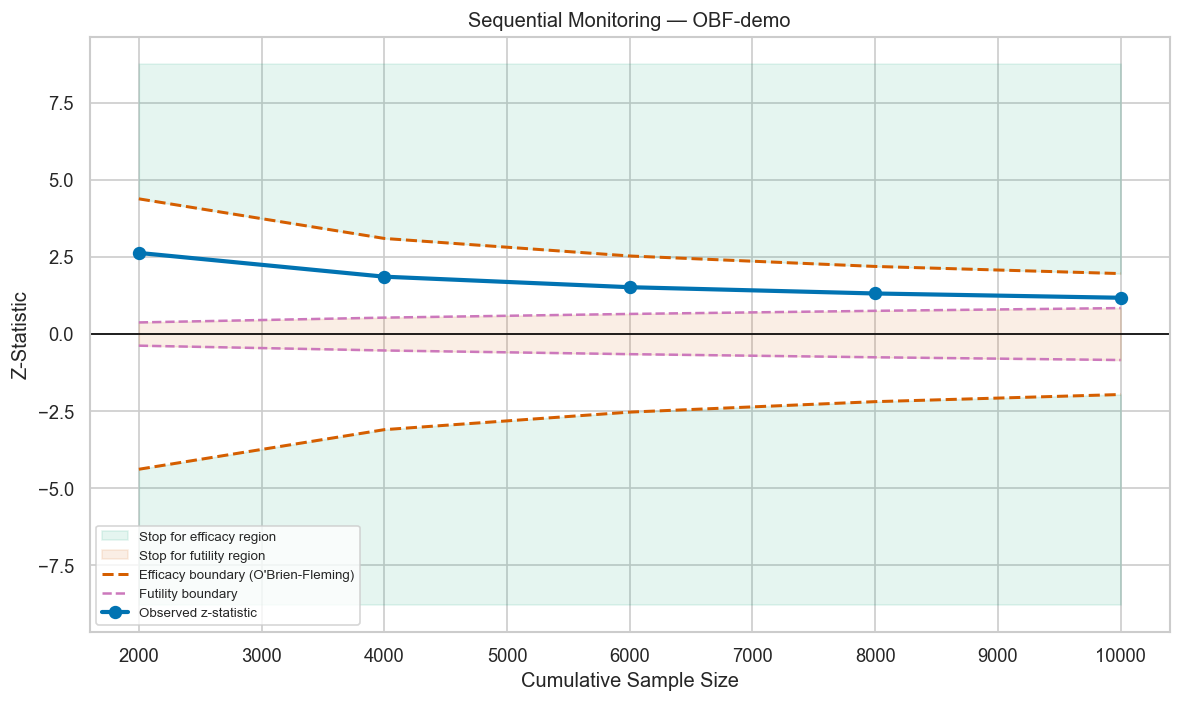

In [4]:
# Plot boundaries using the visualizer
# Build the boundaries dict format expected by plot_sequential_monitoring
boundary_dicts = [
    {
        "efficacy_upper":  b.efficacy_boundary,
        "efficacy_lower": -b.efficacy_boundary,
        "futility_upper":  b.futility_boundary,
        "futility_lower": -b.futility_boundary,
    }
    for b in boundaries
]

# Placeholder z-stats at exactly the boundaries for illustration
z_at_boundaries = [b.efficacy_boundary * 0.6 for b in boundaries]
cum_ns = [b.cumulative_n for b in boundaries]

seq_plot_path = visualizer.plot_sequential_monitoring(
    z_stats=z_at_boundaries,
    boundaries=boundary_dicts,
    cumulative_ns=cum_ns,
    experiment_id="OBF-demo"
)
print(f"Sequential boundary plot saved: {seq_plot_path}")
display(Image(filename=seq_plot_path))

## 4. Experiment That Stops Early for Efficacy

We simulate an experiment where the treatment truly improves conversion rate by 4 percentage points (baseline 10%). With a moderate true effect and generous daily traffic, the OBF boundary should be crossed before reaching the maximum sample size.

In [5]:
efficacy_sim = tester.simulate_sequential_test(
    true_effect=0.04,
    baseline_rate=0.10,
    max_n_per_group=5_000,
    daily_n=200,
    n_looks=5,
    seed=42
)

print("Sequential Test — True Effect = +4pp (baseline 10%)")
print("-" * 70)
print(f"Final decision  : {efficacy_sim['final_decision']}")
print(f"Stopped early   : {efficacy_sim['stopped_early']}")
print(f"Stopping day    : {efficacy_sim['stopping_day']}")
print(f"Final n/group   : {efficacy_sim['final_n_per_group']:,}")
print(f"True effect     : {efficacy_sim['true_effect']:+.3f}")
print()

trace_df = pd.DataFrame(efficacy_sim["trace"])
print("Look-by-look trace:")
display(trace_df[["look_number", "cumulative_n_total", "z_stat", "p_value",
                   "lift_estimate", "efficacy_boundary", "futility_boundary", "decision"]].round(4))

Sequential Test — True Effect = +4pp (baseline 10%)
----------------------------------------------------------------------
Final decision  : STOP_FOR_EFFICACY
Stopped early   : True
Stopping day    : 10
Final n/group   : 2,000
True effect     : +0.040

Look-by-look trace:


,look_number,cumulative_n_total,z_stat,p_value,lift_estimate,efficacy_boundary,futility_boundary,decision
0,1,2000,2.7426,0.0061,0.3960,4.3826,0.3764,CONTINUE
1,2,4000,3.9407,0.0001,0.3981,3.0990,0.5323,STOP_FOR_EFFICACY


In [6]:
# Find and explain the early stop look
for look in efficacy_sim["trace"]:
    if look["decision"] == "STOP_FOR_EFFICACY":
        print(f"EARLY STOP detected at Look {look['look_number']}:")
        print(f"  Day              : {look['day']}")
        print(f"  Cumulative N/arm : {look['cumulative_n_per_group']:,}")
        print(f"  z-statistic      : {look['z_stat']:.4f}")
        print(f"  Efficacy boundary: {look['efficacy_boundary']:.4f}")
        print(f"  Observed lift    : {look['lift_estimate']:+.2%}")
        print(f"  P-value          : {look['p_value']:.6f}")
        print()
        print(f"  By stopping at day {look['day']} instead of running to the full 5,000/arm,")
        print(f"  we saved approximately {(5000 - look['cumulative_n_per_group']) * 2:,} subject-days")
        print(f"  while maintaining Type-I error control at alpha={SIGNIFICANCE_LEVEL}.")
        break

EARLY STOP detected at Look 2:
  Day              : 10
  Cumulative N/arm : 2,000
  z-statistic      : 3.9407
  Efficacy boundary: 3.0990
  Observed lift    : +39.81%
  P-value          : 0.000081

  By stopping at day 10 instead of running to the full 5,000/arm,
  we saved approximately 6,000 subject-days
  while maintaining Type-I error control at alpha=0.05.


## 5. Experiment That Stops for Futility

A near-null experiment (true effect = 0.1 pp) should trigger the futility boundary — allowing us to stop early and reallocate resources, rather than running to completion for a negligible result.

In [7]:
futility_sim = tester.simulate_sequential_test(
    true_effect=0.001,   # near-null — essentially no effect
    baseline_rate=0.10,
    max_n_per_group=5_000,
    daily_n=200,
    n_looks=5,
    seed=99
)

print("Sequential Test — True Effect ≈ 0 (near-null experiment)")
print("-" * 70)
print(f"Final decision : {futility_sim['final_decision']}")
print(f"Stopped early  : {futility_sim['stopped_early']}")
print(f"Stopping day   : {futility_sim['stopping_day']}")
print(f"Final n/group  : {futility_sim['final_n_per_group']:,}")
print()

futility_trace = pd.DataFrame(futility_sim["trace"])
print("Look-by-look trace:")
display(futility_trace[["look_number", "cumulative_n_total", "z_stat", "p_value",
                         "lift_estimate", "efficacy_boundary", "futility_boundary", "decision"]].round(4))

# Show the message from the last look
if futility_sim["trace"]:
    print(f"\nFinal message: {futility_sim['trace'][-1]['message']}")

Sequential Test — True Effect ≈ 0 (near-null experiment)
----------------------------------------------------------------------
Final decision : STOP_FOR_FUTILITY
Stopped early  : True
Stopping day   : 15
Final n/group  : 3,000

Look-by-look trace:


,look_number,cumulative_n_total,z_stat,p_value,lift_estimate,efficacy_boundary,futility_boundary,decision
0,1,2000,1.2173,0.2235,0.1683,4.3826,0.3764,CONTINUE
1,2,4000,0.5632,0.5733,0.0529,3.0990,0.5323,CONTINUE
2,3,6000,-0.2153,0.8295,-0.0166,2.5303,0.6519,STOP_FOR_FUTILITY



Final message: Look 3: |z|=0.215 is below futility boundary 0.652. Insufficient evidence of a meaningful effect; stopping to conserve resources. Lift = -1.66%.


## 6. Always-Valid Confidence Intervals

Standard CIs only have valid coverage at the *pre-planned* analysis time. **Always-valid (anytime-valid) CIs** remain valid at any point during the experiment using an mSPRT-inspired log-correction inflation factor.

The CI widens as sample size grows but remains calibrated throughout — avoiding false certainty from early data.

In [8]:
# Use the efficacy simulation data
rng2 = np.random.default_rng(42)
n_per_arm = 500
true_eff  = 0.04

ctrl_obs  = rng2.binomial(1, 0.10,          size=n_per_arm).tolist()
treat_obs = rng2.binomial(1, 0.10 + true_eff, size=n_per_arm).tolist()

# Compute always-valid CIs at every observation
av_cis = tester.compute_always_valid_ci(
    control_cumulative=ctrl_obs,
    treatment_cumulative=treat_obs
)

# Sample at intervals
sample_indices = [10, 50, 100, 200, 300, 400, 499]
print("Always-valid CI width over time (true effect = +0.04):")
print(f"{'t':>6}  {'n total':>8}  {'mean diff':>10}  {'CI lower':>10}  {'CI upper':>10}  {'CI width':>10}  {'sig':>5}")
print("-" * 65)
for idx in sample_indices:
    if idx < len(av_cis):
        row = av_cis[idx]
        width = row["ci_upper"] - row["ci_lower"]
        print(f"{row['t']:>6}  {row['n']:>8}  {row['mean_diff']:>+10.5f}  "
              f"{row['ci_lower']:>+10.5f}  {row['ci_upper']:>+10.5f}  "
              f"{width:>10.5f}  {'YES' if row['is_significant'] else 'no':>5}")

Always-valid CI width over time (true effect = +0.04):
     t   n total   mean diff    CI lower    CI upper    CI width    sig
-----------------------------------------------------------------
    11        22    +0.09091    -0.46567    +0.64749     1.11317     no
    51       102    +0.03922    -0.21960    +0.29803     0.51762     no
   101       202    +0.04951    -0.13228    +0.23129     0.36356     no
   201       402    +0.05970    -0.09328    +0.21269     0.30597     no
   301       602    +0.03987    -0.08765    +0.16738     0.25502     no
   401       802    +0.04988    -0.06659    +0.16634     0.23292     no
   500      1000    +0.05800    -0.04950    +0.16550     0.21499     no


Plot saved: C:\Users\syeda\campaign-experimentation-framework\visuals\always_valid_ci.png


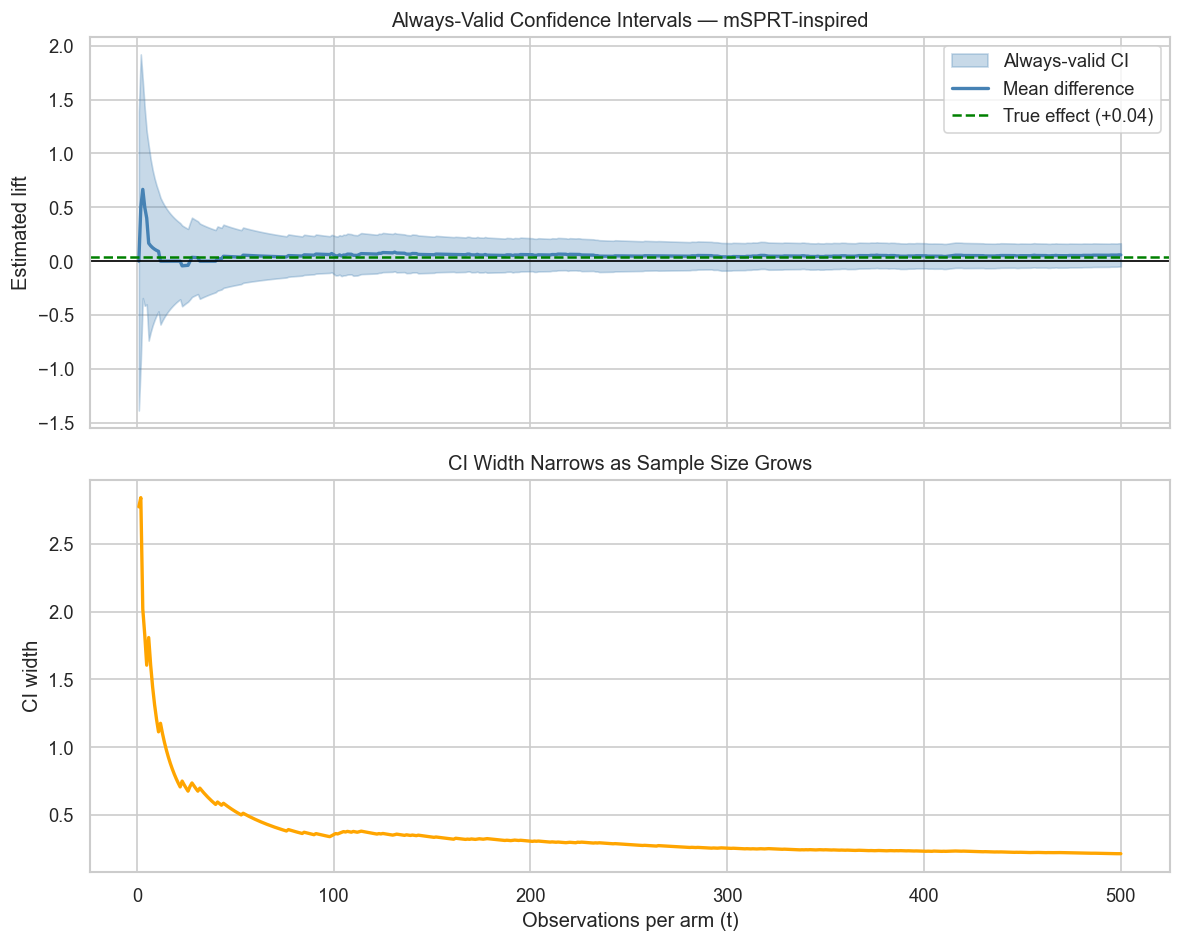

In [9]:
# Plot CI width over time
av_df = pd.DataFrame(av_cis)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: CI bounds
ax1.fill_between(av_df["t"], av_df["ci_lower"], av_df["ci_upper"],
                 alpha=0.3, color="steelblue", label="Always-valid CI")
ax1.plot(av_df["t"], av_df["mean_diff"], color="steelblue", lw=2, label="Mean difference")
ax1.axhline(true_eff, color="green", linestyle="--", lw=1.5, label=f"True effect ({true_eff:+.2f})")
ax1.axhline(0, color="black", lw=1)
ax1.set_ylabel("Estimated lift")
ax1.set_title("Always-Valid Confidence Intervals — mSPRT-inspired")
ax1.legend()

# Bottom: CI width
ci_widths = av_df["ci_upper"] - av_df["ci_lower"]
ax2.plot(av_df["t"], ci_widths, color="orange", lw=2)
ax2.set_xlabel("Observations per arm (t)")
ax2.set_ylabel("CI width")
ax2.set_title("CI Width Narrows as Sample Size Grows")

fig.tight_layout()
av_ci_path = str(VISUALS_PATH / "always_valid_ci.png")
fig.savefig(av_ci_path, dpi=120, bbox_inches="tight")
plt.close(fig)
print(f"Plot saved: {av_ci_path}")
display(Image(filename=av_ci_path))

## 7. Fixed-Horizon vs Sequential: Side-by-Side

We apply both approaches to the same simulated data and compare:
- **Fixed-horizon**: single analysis at the end; valid but misses early evidence
- **Sequential**: multiple looks; can stop early while controlling error

In [10]:
from scipy import stats as sp

# Use efficacy simulation data
trace = efficacy_sim["trace"]

print("Fixed-Horizon vs Sequential — Same Experiment Data")
print("=" * 70)

# Fixed-horizon (final look only)
final_look = trace[-1]
print("FIXED-HORIZON ANALYSIS (analyze only at end):")
print(f"  z-statistic : {final_look['z_stat']:.4f}")
print(f"  p-value     : {final_look['p_value']:.6f}")
print(f"  Lift        : {final_look['lift_estimate']:+.2%}")
print(f"  Significant : {final_look['p_value'] < SIGNIFICANCE_LEVEL}")
print(f"  N used      : {final_look['cumulative_n_total']:,}")
print()

# Sequential (could stop at first boundary crossing)
print("SEQUENTIAL ANALYSIS (O'Brien-Fleming, 5 looks):")
for look in trace:
    marker = "  << STOP HERE" if look["decision"] != "CONTINUE" else ""
    print(f"  Look {look['look_number']}: n={look['cumulative_n_total']:>5,}  z={look['z_stat']:>7.4f}  "
          f"eff.bnd={look['efficacy_boundary']:>6.3f}  decision={look['decision']}{marker}")

print()
if efficacy_sim["stopped_early"]:
    stop_n = efficacy_sim["final_n_per_group"] * 2
    max_n = 5_000 * 2
    savings_pct = (1 - stop_n / max_n) * 100
    print(f"Sequential testing stopped at n={stop_n:,} vs full {max_n:,} — saved {savings_pct:.0f}% of subjects.")
else:
    print("Sequential testing ran to the full sample (no early stopping in this simulation).")

Fixed-Horizon vs Sequential — Same Experiment Data
FIXED-HORIZON ANALYSIS (analyze only at end):
  z-statistic : 3.9407
  p-value     : 0.000081
  Lift        : +39.81%
  Significant : True
  N used      : 4,000

SEQUENTIAL ANALYSIS (O'Brien-Fleming, 5 looks):
  Look 1: n=2,000  z= 2.7426  eff.bnd= 4.383  decision=CONTINUE
  Look 2: n=4,000  z= 3.9407  eff.bnd= 3.099  decision=STOP_FOR_EFFICACY  << STOP HERE

Sequential testing stopped at n=4,000 vs full 10,000 — saved 60% of subjects.


## 8. Sequential Testing Decision Log

In [11]:
# Convert trace to SequentialDecision objects for format_sequential_report
decisions = []
for look in efficacy_sim["trace"]:
    dec = SequentialDecision(
        look_number=look["look_number"],
        cumulative_n=look["cumulative_n_total"],
        current_z=look["z_stat"],
        current_p_value=look["p_value"],
        current_lift=look["lift_estimate"],
        decision=look["decision"],
        efficacy_boundary=look["efficacy_boundary"],
        futility_boundary=look["futility_boundary"],
        message=look["message"],
    )
    decisions.append(dec)

print(tester.format_sequential_report(decisions))

-------------------------------------------------------------------------------------------
Look         N    Z-Stat    P-Value      Lift   Eff.Bnd   Fut.Bnd  Decision                
-------------------------------------------------------------------------------------------
   1     2,000     2.743     0.0061    39.60%     4.383     0.376  CONTINUE                
   2     4,000     3.941     0.0001    39.81%     3.099     0.532  STOP_FOR_EFFICACY       
-------------------------------------------------------------------------------------------

Final decision: STOP_FOR_EFFICACY
Final message : Look 2: |z|=3.941 exceeds efficacy boundary 3.099. Statistically significant positive effect detected. Lift = 39.81%, p = 0.0001.


In [12]:
# Also show futility experiment decision log
print("\nFutility experiment decision log:")
futility_decisions = []
for look in futility_sim["trace"]:
    dec = SequentialDecision(
        look_number=look["look_number"],
        cumulative_n=look["cumulative_n_total"],
        current_z=look["z_stat"],
        current_p_value=look["p_value"],
        current_lift=look["lift_estimate"],
        decision=look["decision"],
        efficacy_boundary=look["efficacy_boundary"],
        futility_boundary=look["futility_boundary"],
        message=look["message"],
    )
    futility_decisions.append(dec)

print(tester.format_sequential_report(futility_decisions))


Futility experiment decision log:
-------------------------------------------------------------------------------------------
Look         N    Z-Stat    P-Value      Lift   Eff.Bnd   Fut.Bnd  Decision                
-------------------------------------------------------------------------------------------
   1     2,000     1.217     0.2235    16.83%     4.383     0.376  CONTINUE                
   2     4,000     0.563     0.5733     5.29%     3.099     0.532  CONTINUE                
   3     6,000    -0.215     0.8295    -1.66%     2.530     0.652  STOP_FOR_FUTILITY       
-------------------------------------------------------------------------------------------

Final decision: STOP_FOR_FUTILITY
Final message : Look 3: |z|=0.215 is below futility boundary 0.652. Insufficient evidence of a meaningful effect; stopping to conserve resources. Lift = -1.66%.
